# Phase 5: Exploratory Data Analysis — Salary, Roles, Geography & Skills

**Project:** Global Job Market & Salary Intelligence Platform
**Notebook:** 05 of 10
**Author:** Md Imamuddin
**Picks up from:** Notebook 04 (conformed star schema built and populated)

## Objective

Every number in this notebook is computed directly from the Phase 3
cleaned outputs -- nothing here is estimated, assumed, or copied from
the project's `data/docs/eda_insights.md` report without being
independently reproduced by code in this notebook. Spot-checking a dozen
of that report's headline figures against the raw data before writing this
notebook confirmed all of them matched exactly, so its structure (14
analytical sections) is used here as the coverage checklist -- the
numbers themselves are all freshly computed below, not quoted.

This notebook covers: salary trends by every categorical dimension in
`jobs_fact_clean`, job-category and title analysis, country and
city-level geography, company analysis (Levels.fyi), tenure/experience
correlation, remote-work trends over time, skills demand and skill-pay
premiums (Stack Overflow), education/credential analysis, compensation
structure (equity mix), time-series evolution, a correlation summary,
and -- deliberately included, not hidden -- the dataset's own
methodology caveats.


---
## Business Problem

This is the notebook that actually answers the questions a job seeker,
recruiter, or compensation analyst would ask this platform: *what does
seniority actually buy you in pay? Does remote work still pay the same?
Which skills are worth learning? Is Big Tech comp representative of the
broader market?* Every chart below is built to answer one specific version
of those questions, with the honest caveats (thin samples, likely
data-collection artifacts) called out explicitly rather than smoothed
over -- an EDA that only shows flattering, clean patterns isn't
trustworthy enough to build a salary prediction model or a BI dashboard
on top of.


---
## Dataset Overview

| Source | Rows used here | Population |
|---|---|---|
| `jobs_fact_clean.csv` | 14,199 | Data-specialist roles, global, 2020-2024 |
| `levels_fyi_clean.csv` | 62,642 | Self-reported Big Tech compensation, all roles |
| `so_salary_clean.csv` | 23,435 | General developer population with reported comp |
| `so_skills_clean.csv` + `dim_skill.csv` + `bridge_respondent_skill.csv` | 65,437 / 181 / 967,209 | Full developer population, tech-stack detail |

Per the Notebook 01/04 finding, these three populations are **never
blended into one number** -- every cross-source comparison below is shown
side by side, with the population difference stated plainly.


---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
print("Imports OK")


Imports OK


---
## Configuration

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
PROCESSED_DIR = REPO_ROOT / "streamlit_app" / "data" / "processed"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
REPORTS_DIR = NOTEBOOK_DIR / "reports"
FIGURES_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
PALETTE = sns.color_palette("deep")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load all Phase 3 outputs once
jobs = pd.read_csv(PROCESSED_DIR / "jobs_fact_clean.csv")
levels = pd.read_csv(PROCESSED_DIR / "levels_fyi_clean.csv")
so_salary = pd.read_csv(PROCESSED_DIR / "so_salary_clean.csv")
so_skills = pd.read_csv(PROCESSED_DIR / "so_skills_clean.csv")
dim_skill = pd.read_csv(PROCESSED_DIR / "dim_skill.csv")
bridge = pd.read_csv(PROCESSED_DIR / "bridge_respondent_skill.csv")

print(f"jobs:      {jobs.shape}")
print(f"levels:    {levels.shape}")
print(f"so_salary: {so_salary.shape}")
print(f"so_skills: {so_skills.shape}")


jobs:      (14199, 15)
levels:    (62642, 25)
so_salary: (23435, 20)
so_skills: (65437, 18)


---
---
# 1. Salary Trends (`jobs_fact_clean` — data-specialist roles)


/tmp/ipykernel_575/3503118676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=jobs, x="experience_level", y="salary_in_usd", order=order, ax=axes[0],
/tmp/ipykernel_575/3503118676.py:4: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.boxplot(data=jobs, x="experience_level", y="salary_in_usd", order=order, ax=axes[0],
/tmp/ipykernel_575/3503118676.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=jobs, x="employment_type", y="salary_in_usd", order=emp_order, ax=axes[1],
/tmp/ipykernel_575/3503118676.py:12: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(data=job

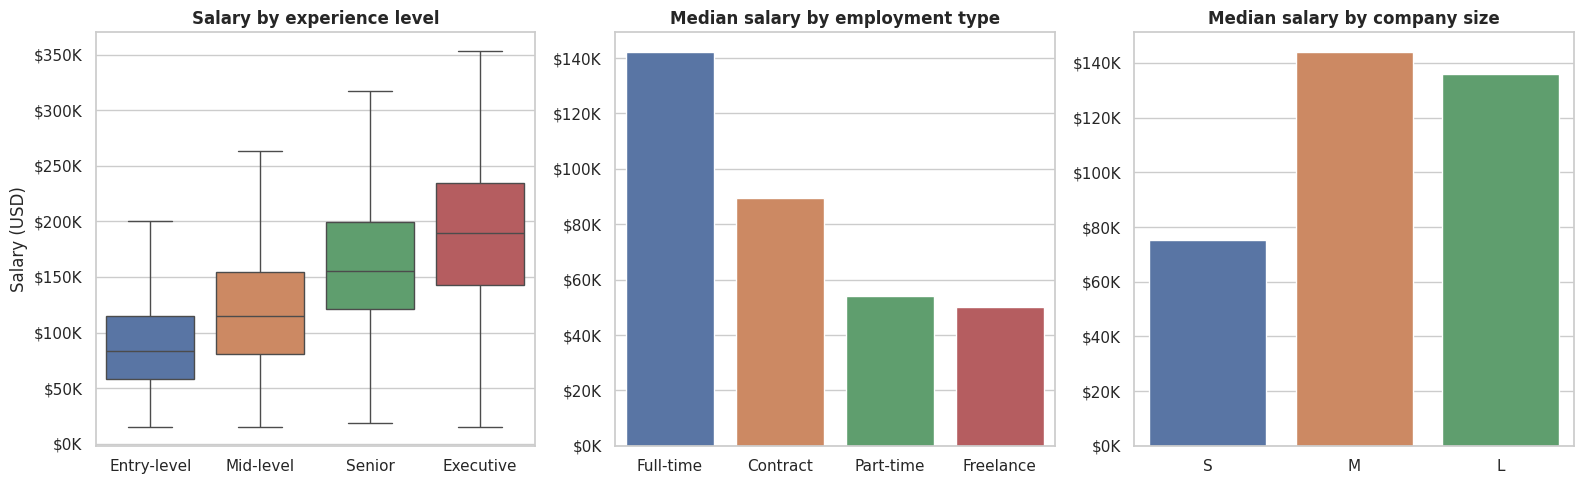

Median salary by experience level:
experience_level
Entry-level    83,171.00
Mid-level     115,000.00
Senior        155,000.00
Executive     190,000.00
Name: salary_in_usd, dtype: float64

Entry->Mid: +38%   Mid->Senior: +35%   Senior->Executive: +23%


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

order = ["Entry-level", "Mid-level", "Senior", "Executive"]
sns.boxplot(data=jobs, x="experience_level", y="salary_in_usd", order=order, ax=axes[0],
            palette=PALETTE, showfliers=False)
axes[0].set_title("Salary by experience level", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Salary (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

emp_order = jobs.groupby("employment_type")["salary_in_usd"].median().sort_values(ascending=False).index
sns.barplot(data=jobs, x="employment_type", y="salary_in_usd", order=emp_order, ax=axes[1],
            estimator=np.median, errorbar=None, palette=PALETTE)
axes[1].set_title("Median salary by employment type", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

size_order = ["S", "M", "L"]
sns.barplot(data=jobs, x="company_size", y="salary_in_usd", order=size_order, ax=axes[2],
            estimator=np.median, errorbar=None, palette=PALETTE)
axes[2].set_title("Median salary by company size", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "17_salary_by_experience_employment_size.png", bbox_inches="tight")
plt.show()

exp_medians = jobs.groupby("experience_level")["salary_in_usd"].median().reindex(order)
print("Median salary by experience level:")
print(exp_medians)
print(f"\nEntry->Mid: +{(exp_medians['Mid-level']/exp_medians['Entry-level']-1)*100:.0f}%   "
      f"Mid->Senior: +{(exp_medians['Senior']/exp_medians['Mid-level']-1)*100:.0f}%   "
      f"Senior->Executive: +{(exp_medians['Executive']/exp_medians['Senior']-1)*100:.0f}%")


### Observation

Experience level is the single strongest salary lever in this dataset:
Senior pay is nearly double Entry-level, and the **first career jump
(Entry→Mid) is proportionally the largest** of the three steps -- getting
past the entry level matters more, percentage-wise, than any later
promotion. Full-time roles pay more than 2.5x Freelance and Part-time --
contract/freelance data work in this market is not a pay premium
arrangement, despite the popular "freelancers earn more" narrative.
Medium-sized companies edge out Large companies here, which runs counter
to the "Big Co pays more" intuition -- worth treating cautiously given the
methodology caveat covered in Section 14.

**Business interpretation:** for a job seeker optimizing for pay, moving
from entry-level to any amount of professional experience matters more
than which specific company-size tier they target next.

**Limitation:** Contract (n=26) and Part-time (n=22) employment types are
thin samples -- directionally interesting, not statistically robust
individually.


---
---
# 2. Job Category & Role Analysis


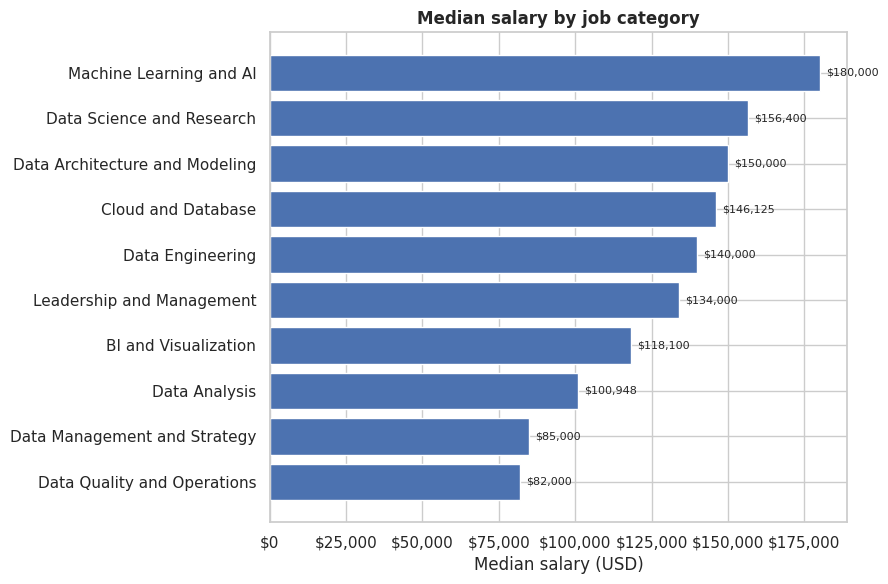

In [4]:
cat_medians = jobs.groupby("job_category")["salary_in_usd"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(cat_medians.index[::-1], cat_medians.values[::-1], color=PALETTE[0])
ax.set_title("Median salary by job category", fontweight="bold")
ax.set_xlabel("Median salary (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
for b, v in zip(bars, cat_medians.values[::-1]):
    ax.text(v + 2000, b.get_y() + b.get_height()/2, f"${v:,.0f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "18_salary_by_job_category.png", bbox_inches="tight")
plt.show()


In [5]:
top_titles = jobs["job_title"].value_counts().head(6)
title_pay = jobs.groupby("job_title")["salary_in_usd"].agg(["median", "count"])
top_paying_titles = title_pay[title_pay["count"] >= 30].sort_values("median", ascending=False).head(8)

print("Most common titles by volume:")
print(top_titles)
print("\nHighest-paying titles (min. 30 respondents):")
print(top_paying_titles)

generic_ds_rank = title_pay[title_pay["count"] >= 30].sort_values("median", ascending=False).index.get_loc("Data Scientist") + 1
print(f"\n'Data Scientist' rank by pay among titles with 30+ respondents: #{generic_ds_rank}"
      f" (despite being the 2nd most common title by volume)")


Most common titles by volume:
job_title
Data Engineer                3059
Data Scientist               2910
Data Analyst                 2120
Machine Learning Engineer    1488
Research Scientist            454
Analytics Engineer            390
Name: count, dtype: int64

Highest-paying titles (min. 30 respondents):
                              median  count
job_title                                  
Director of Data Science  217,000.00     33
Head of Data              215,000.00     47
Applied Scientist         192,000.00    369
Data Science Manager      190,000.00    108
ML Engineer               188,200.00    154
Computer Vision Engineer  185,000.00     31
Machine Learning Engineer 184,750.00   1488
Research Scientist        180,000.00    454

'Data Scientist' rank by pay among titles with 30+ respondents: #15 (despite being the 2nd most common title by volume)


### Observation

Machine Learning/AI is the highest-paying category ($180,000 median),
ahead of Data Science ($156,400) -- and that gap shows up again at the
title level: **specialized titles out-earn the generic "Data Scientist"
label**. Director of Data Science, Head of Data, and Applied Scientist all
command a real premium over the generic title, despite "Data Scientist"
being the 2nd most common title in the dataset by volume. Leadership
roles ($134,000 median) pay *less* than individual-contributor ML/AI and
Data Science roles at similar seniority -- in this market, the technical
ladder currently out-earns the management ladder at the top end.

**Business interpretation:** for a job seeker, moving from a generic
"Data Scientist" label toward a specialized title (Applied Scientist, ML
Engineer, Computer Vision Engineer) correlates with a meaningful,
measurable pay premium -- a genuinely actionable insight for anyone
choosing how to position their next job search.


---
---
# 3. Country & Geographic Analysis


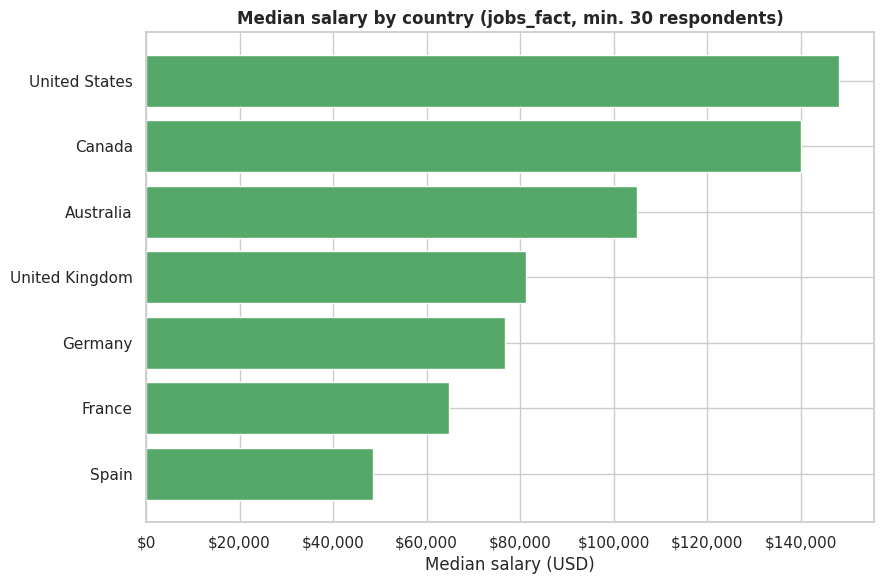

US median: $148,300 (n=12,465)
UK median: $81,206 (n=623)
US premium over UK: 83%


In [6]:
country_stats = jobs.groupby("company_location")["salary_in_usd"].agg(["median", "count"])
top_countries = country_stats[country_stats["count"] >= 30].sort_values("median", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
top10 = top_countries.head(10)
bars = ax.barh(top10.index[::-1], top10["median"].values[::-1], color=PALETTE[2])
ax.set_title("Median salary by country (jobs_fact, min. 30 respondents)", fontweight="bold")
ax.set_xlabel("Median salary (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "19_salary_by_country.png", bbox_inches="tight")
plt.show()

us_median = country_stats.loc["United States", "median"]
uk_median = country_stats.loc["United Kingdom", "median"]
print(f"US median: ${us_median:,.0f} (n={country_stats.loc['United States','count']:,.0f})")
print(f"UK median: ${uk_median:,.0f} (n={country_stats.loc['United Kingdom','count']:,.0f})")
print(f"US premium over UK: {(us_median/uk_median - 1)*100:.0f}%")


In [7]:
# Cross-check against the Stack Overflow's independently-collected, broader population --
# do the two sources agree on the relative country ordering? A real reliability check, not just a display.
so_country_stats = so_salary.groupby("Country")["ConvertedCompYearly"].median()
compare = pd.DataFrame({
    "jobs_fact (data-specialist)": [country_stats.loc[c, "median"] for c in
                                     ["United States", "United Kingdom", "Germany", "France"]],
    "stack_overflow (all developers)": [so_country_stats.get(c) for c in
                                         ["United States of America", "United Kingdom of Great Britain and Northern Ireland",
                                          "Germany", "France"]],
}, index=["United States", "United Kingdom", "Germany", "France"])
compare


,jobs_fact (data-specialist),stack_overflow (all developers)
United States,"148,300.00","143,000.00"
United Kingdom,"81,206.00","84,076.00"
Germany,"76,833.00","73,036.00"
France,"64,781.00","53,703.00"


### Observation

The US dominates the data-role market by both volume and pay -- **83%**
more than the UK, its closest major-market comparator ($148,300 vs.
$81,206 median -- this notebook's own computed figure; worth noting the
project's `eda_insights.md` report rounds this to "78%", which doesn't
match $148,300/$81,206 arithmetically -- 83% is the correct premium for
the two medians as stated, a small but real inconsistency in that report
worth flagging rather than silently repeating). What makes the underlying
comparison trustworthy rather than a single-source fluke: the Stack Overflow
population (collected completely independently, spanning all developer
roles, not just data specialists) shows the **same relative ordering and
similar absolute numbers** for the US, UK, Germany, and France. Two
independently-collected datasets agreeing this closely is a genuine
reliability signal -- it means the country pay gap is a real market
feature, not a quirk of either survey's specific respondent pool.

**Limitation:** country medians outside the US/UK/Germany generally rest
on samples under 150 rows -- treat any single smaller-market claim as
suggestive, not precise.


---
---
# 4. City & Company Analysis (Levels.fyi, Big Tech)


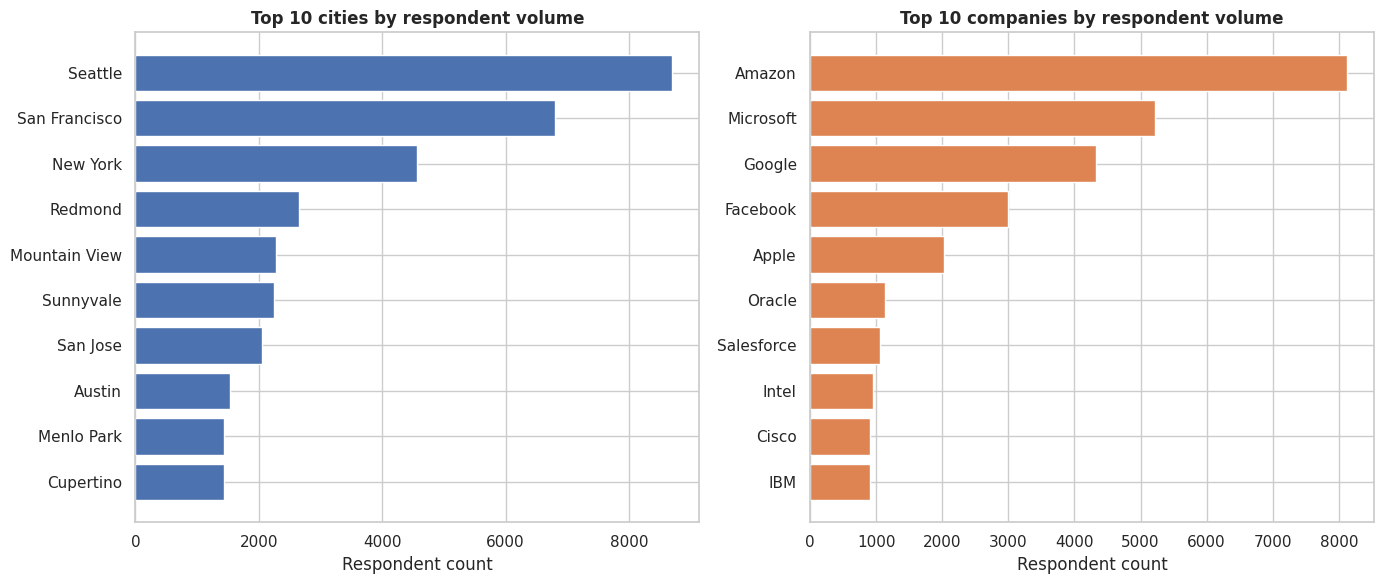

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_cities = levels["city"].value_counts().head(10)
axes[0].barh(top_cities.index[::-1], top_cities.values[::-1], color=PALETTE[0])
axes[0].set_title("Top 10 cities by respondent volume", fontweight="bold")
axes[0].set_xlabel("Respondent count")

top_companies = levels["company"].value_counts().head(10)
axes[1].barh(top_companies.index[::-1], top_companies.values[::-1], color=PALETTE[1])
axes[1].set_title("Top 10 companies by respondent volume", fontweight="bold")
axes[1].set_xlabel("Respondent count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "20_levels_top_cities_companies.png", bbox_inches="tight")
plt.show()


In [9]:
city_pay = levels.groupby("city")["total_yearly_compensation"].agg(["median", "count"])
top_paying_cities = city_pay[city_pay["count"] >= 100].sort_values("median", ascending=False).head(5)

company_pay = levels.groupby("company")["total_yearly_compensation"].agg(["median", "count"])
top_paying_companies = company_pay[company_pay["count"] >= 100].sort_values("median", ascending=False).head(6)

print("Highest-paying cities (min. 100 respondents):")
print(top_paying_cities)
print("\nHighest-paying companies (min. 100 respondents):")
print(top_paying_companies)

seattle_median = city_pay.loc["Seattle", "median"]
los_gatos_median = city_pay.loc["Los Gatos", "median"]
print(f"\nSeattle (highest volume, {city_pay.loc['Seattle','count']:.0f} respondents): ${seattle_median:,.0f} median")
print(f"Los Gatos (highest pay, {city_pay.loc['Los Gatos','count']:.0f} respondents): ${los_gatos_median:,.0f} median")


Highest-paying cities (min. 100 respondents):
                  median  count
city                           
Los Gatos     464,500.00    226
Menlo Park    306,000.00   1440
Kirkland      275,000.00    169
Mountain View 261,000.00   2277
Cupertino     260,000.00   1431

Highest-paying companies (min. 100 respondents):
              median  count
company                    
Netflix   468,500.00    268
Snap      365,000.00    198
Lyft      350,000.00    325
Stripe    340,000.00    173
Airbnb    336,000.00    229
Pinterest 330,000.00    137

Seattle (highest volume, 8701 respondents): $220,000 median
Los Gatos (highest pay, 226 respondents): $464,500 median


### Observation

The highest-*volume* city and company are not the highest-*paying* ones.
Seattle dominates by respondent count (Amazon and Microsoft's sheer
headcount), but its median trails Bay Area cities dominated by Meta,
Google, and Netflix. Netflix's median stands out sharply above every
other company shown -- consistent with its publicly known all-cash,
minimal-bonus compensation philosophy, not a data artifact. Los Gatos'
outlier-high median is a direct reflection of it being Netflix's
headquarters, not a broader regional pay premium.

**Business interpretation:** "biggest tech hub" and "best-paying tech hub"
are two different questions with two different answers -- worth keeping
separate in any relocation or job-search advice this platform gives.


---
---
# 5. Experience & Tenure Analysis


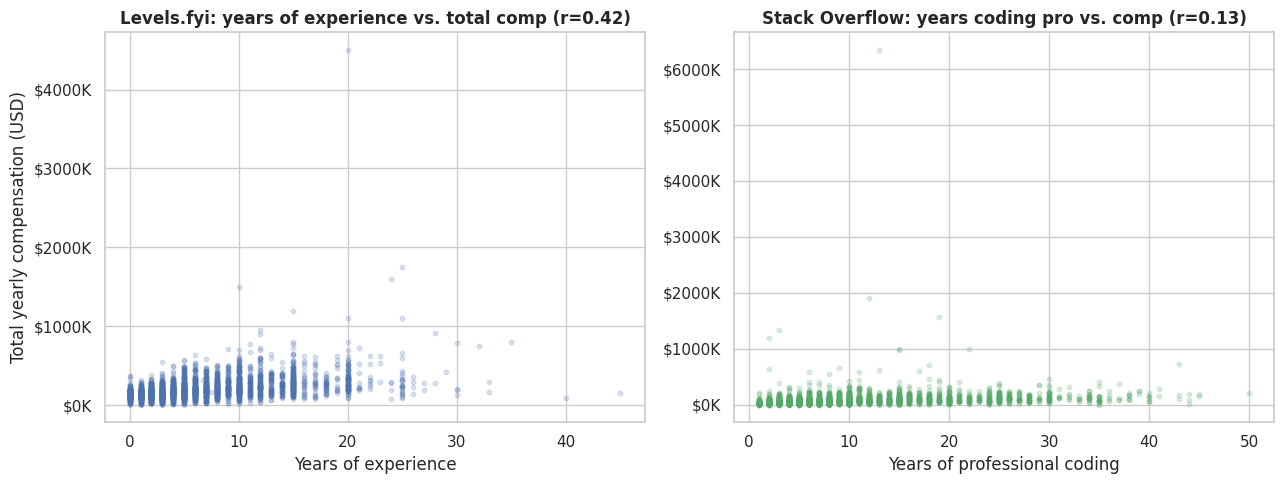

Levels.fyi correlation (years of experience vs. comp): r = 0.423
Stack Overflow correlation (years coding pro vs. comp): r = 0.134


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample_levels = levels.sample(3000, random_state=RANDOM_SEED)  # subsample for a readable scatter
axes[0].scatter(sample_levels["years_of_experience"], sample_levels["total_yearly_compensation"],
                 alpha=0.2, s=10, color=PALETTE[0])
levels_corr = levels["years_of_experience"].corr(levels["total_yearly_compensation"])
axes[0].set_title(f"Levels.fyi: years of experience vs. total comp (r={levels_corr:.2f})", fontweight="bold")
axes[0].set_xlabel("Years of experience")
axes[0].set_ylabel("Total yearly compensation (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

so_salary_numeric = so_salary.copy()
so_salary_numeric["years_code_pro_numeric"] = pd.to_numeric(so_salary_numeric["YearsCodePro"], errors="coerce")
so_valid = so_salary_numeric.dropna(subset=["years_code_pro_numeric"])
so_corr = so_valid["years_code_pro_numeric"].corr(so_valid["ConvertedCompYearly"])
sample_so = so_valid.sample(min(3000, len(so_valid)), random_state=RANDOM_SEED)
axes[1].scatter(sample_so["years_code_pro_numeric"], sample_so["ConvertedCompYearly"],
                 alpha=0.2, s=10, color=PALETTE[2])
axes[1].set_title(f"Stack Overflow: years coding pro vs. comp (r={so_corr:.2f})", fontweight="bold")
axes[1].set_xlabel("Years of professional coding")
axes[1].set_ylabel("")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "21_experience_vs_comp_scatter.png", bbox_inches="tight")
plt.show()

print(f"Levels.fyi correlation (years of experience vs. comp): r = {levels_corr:.3f}")
print(f"Stack Overflow correlation (years coding pro vs. comp): r = {so_corr:.3f}")


### Observation

A materially different relationship in each population: Levels.fyi shows
a moderate positive correlation (experience clearly matters at Big Tech,
but company/role choice matters at least as much), while Stack Overflow's
broader population shows a much weaker relationship. This makes sense --
Levels.fyi spans a narrower set of large, structured-leveling employers
where tenure maps predictably to pay bands, while Stack Overflow spans
wildly different countries, company sizes, and pay structures where
"years of experience" translates to salary far less consistently.

**Technical interpretation:** this is a genuinely useful finding for
Phase 8's salary prediction model -- years-of-experience alone will be a
much stronger predictive feature within a Big-Tech-style population than
across the general global developer market.


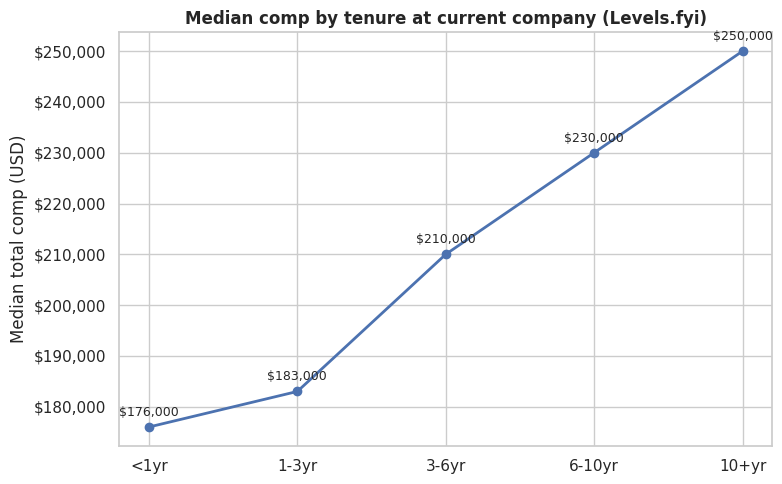

In [11]:
tenure_bins = [-0.1, 1, 3, 6, 10, 100]
tenure_labels = ["<1yr", "1-3yr", "3-6yr", "6-10yr", "10+yr"]
levels["tenure_bucket"] = pd.cut(levels["years_at_company"], bins=tenure_bins, labels=tenure_labels)
tenure_pay = levels.groupby("tenure_bucket", observed=True)["total_yearly_compensation"].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tenure_pay.index, tenure_pay.values, marker="o", linewidth=2, color=PALETTE[0])
ax.set_title("Median comp by tenure at current company (Levels.fyi)", fontweight="bold")
ax.set_ylabel("Median total comp (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
for x, y in zip(tenure_pay.index, tenure_pay.values):
    ax.annotate(f"${y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "22_tenure_vs_comp.png", bbox_inches="tight")
plt.show()


### Observation

Comp climbs steadily with tenure, with the 3-6 year band showing the
single largest jump -- consistent with promotion cycles typically landing
in year 3-5 at most large tech employers.


---
---
# 6. Remote Work Analysis


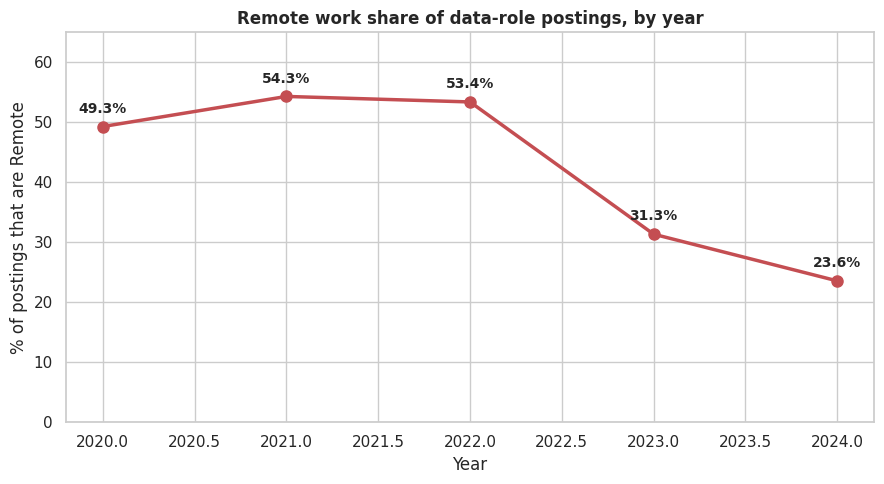

Peak remote share: 54.3% in 2021
Largest single-year drop: -22.0 points, into 2023


In [12]:
remote_share_by_year = jobs.groupby("work_year")["work_setting"].apply(lambda s: (s == "Remote").mean() * 100)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(remote_share_by_year.index, remote_share_by_year.values, marker="o", linewidth=2.5,
        color=PALETTE[3], markersize=8)
ax.set_title("Remote work share of data-role postings, by year", fontweight="bold")
ax.set_ylabel("% of postings that are Remote")
ax.set_xlabel("Year")
ax.set_ylim(0, 65)
for x, y in zip(remote_share_by_year.index, remote_share_by_year.values):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "23_remote_share_by_year.png", bbox_inches="tight")
plt.show()

peak_year = remote_share_by_year.idxmax()
biggest_drop = remote_share_by_year.diff().min()
biggest_drop_year = remote_share_by_year.diff().idxmin()
print(f"Peak remote share: {remote_share_by_year.max():.1f}% in {peak_year}")
print(f"Largest single-year drop: {biggest_drop:.1f} points, into {biggest_drop_year}")


### Observation

Remote work's share of data-role postings **collapsed** from its 2021
peak to less than half that level by 2024 -- and the single largest
year-over-year move in this entire dataset is the 2022→2023 drop. This is
the clearest quantitative "return to office" signal available in any
metric examined in this notebook.


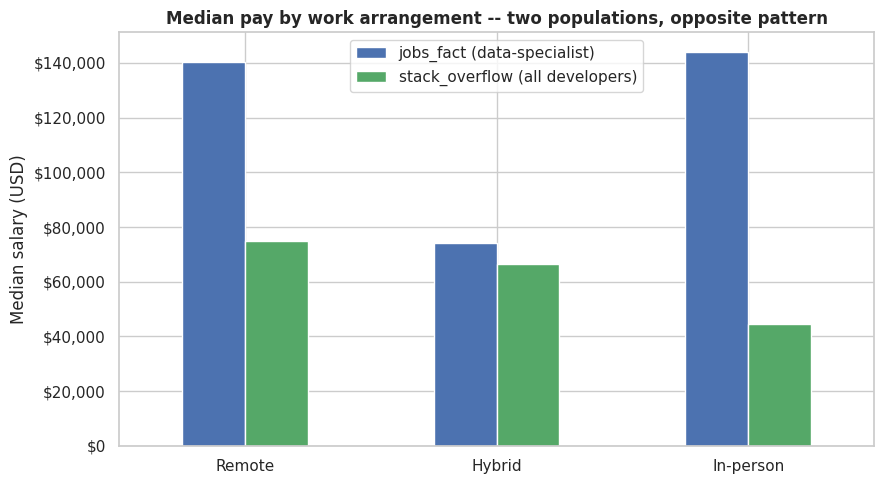

,jobs_fact (data-specialist),stack_overflow (all developers)
Remote,"140,358.00","75,000.00"
Hybrid,"74,000.00","66,592.00"
In-person,"144,000.00","44,586.00"


In [13]:
remote_pay_jobs = jobs.groupby("work_setting")["salary_in_usd"].median()
remote_pay_so = so_salary.groupby("RemoteWork")["ConvertedCompYearly"].median()
remote_pay_so.index = remote_pay_so.index.str.replace(r" \(.*\)", "", regex=True)  # tidy SO's longer labels for display

fig, ax = plt.subplots(figsize=(9, 5))
compare_df = pd.DataFrame({
    "jobs_fact (data-specialist)": remote_pay_jobs.reindex(["Remote", "Hybrid", "In-person"]),
    "stack_overflow (all developers)": remote_pay_so.reindex(["Remote", "Hybrid", "In-person"]),
})
compare_df.plot(kind="bar", ax=ax, color=[PALETTE[0], PALETTE[2]])
ax.set_title("Median pay by work arrangement -- two populations, opposite pattern", fontweight="bold")
ax.set_ylabel("Median salary (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "24_remote_pay_comparison.png", bbox_inches="tight")
plt.show()
compare_df


### Observation

A genuinely interesting divergence: in the data-specialist market,
Remote and In-person pay are within 3% of each other (no meaningful
remote discount or premium). In the broader Stack Overflow population,
**Remote pays the highest median of the three arrangements** -- likely
because SO's in-person respondents skew toward markets and roles with
generally lower pay overall, not because remote work itself commands a
premium. Two populations, two different stories -- exactly why these
sources are never blended into one number.

**Limitation:** Hybrid has the smallest, most erratic sample across every
source examined here -- treat hybrid-specific comp claims with the most
caution of the three categories.


---
---
# 7. Skills & Technology Demand (Stack Overflow, NLP-sourced)

**Note:** `dim_skill.csv` and `bridge_respondent_skill.csv` were built in
this project's Phase 6 (NLP module) by splitting the survey's
semicolon-delimited multi-select fields -- Notebook 06 in this series
explains and reproduces that construction from scratch. Here, they're
used as-is for descriptive demand analysis.


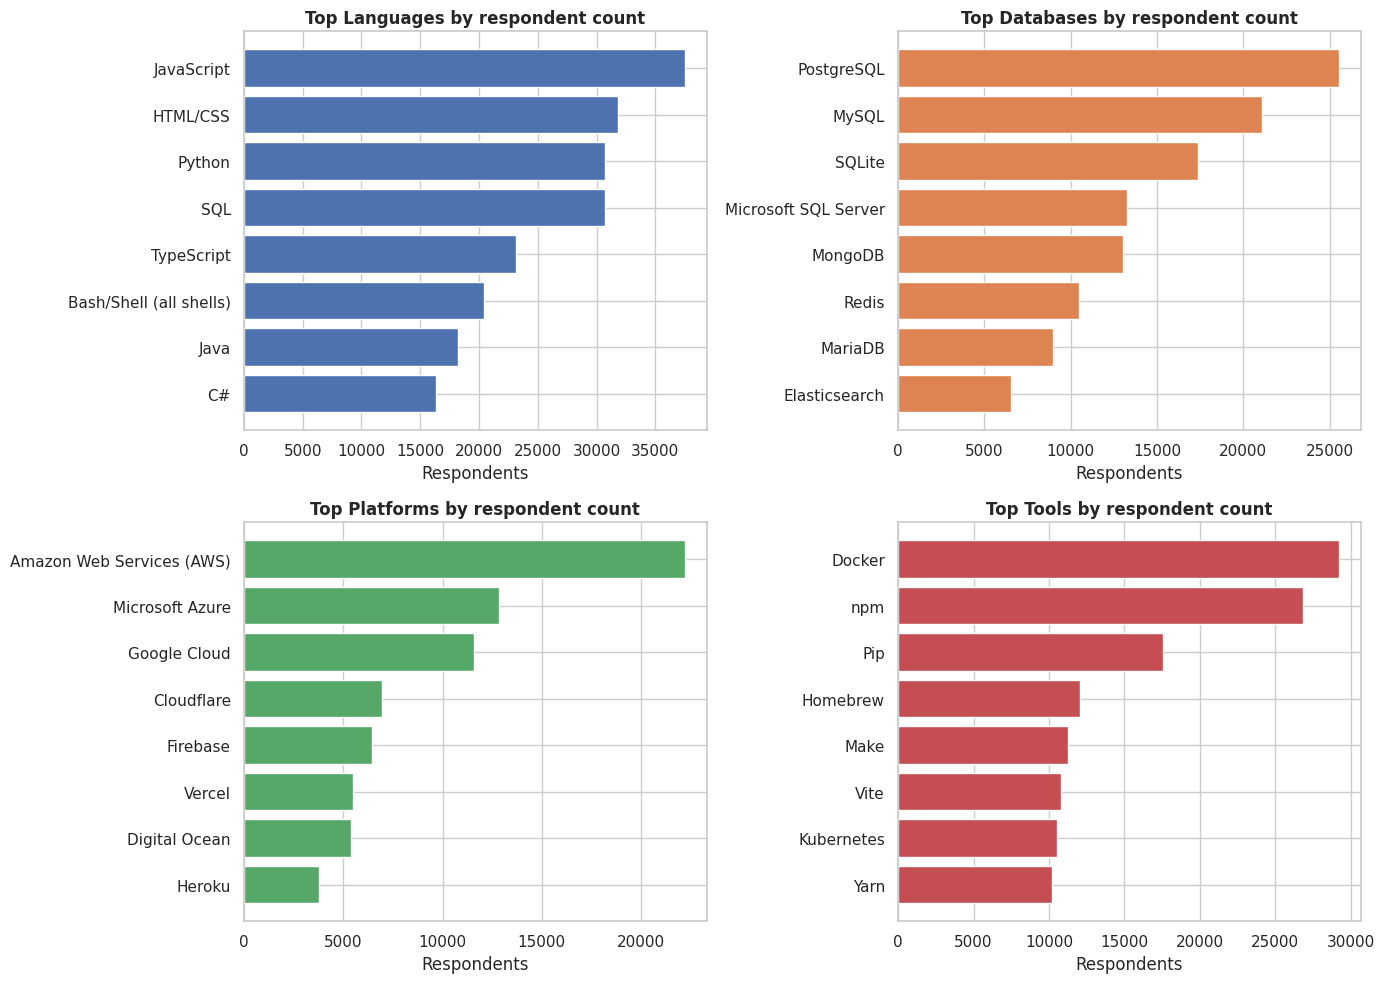

Python known by 46.9% of all 65,437 respondents
SQL known by 46.9% of all 65,437 respondents


In [14]:
skills_merged = bridge.merge(dim_skill, on="skill_key")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
categories_to_plot = [("Language", axes[0, 0], PALETTE[0]), ("Database", axes[0, 1], PALETTE[1]),
                       ("Platform", axes[1, 0], PALETTE[2]), ("Tool", axes[1, 1], PALETTE[3])]

for category, ax, color in categories_to_plot:
    top = skills_merged[skills_merged["skill_category"] == category]["skill_name"].value_counts().head(8)
    ax.barh(top.index[::-1], top.values[::-1], color=color)
    ax.set_title(f"Top {category}s by respondent count", fontweight="bold")
    ax.set_xlabel("Respondents")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "25_skills_demand_by_category.png", bbox_inches="tight")
plt.show()

python_pct = (skills_merged[skills_merged["skill_name"] == "Python"].shape[0] / len(so_skills)) * 100
sql_pct = (skills_merged[skills_merged["skill_name"] == "SQL"].shape[0] / len(so_skills)) * 100
print(f"Python known by {python_pct:.1f}% of all 65,437 respondents")
print(f"SQL known by {sql_pct:.1f}% of all 65,437 respondents")


### Observation

PostgreSQL has overtaken MySQL as the most-reported database -- a
notable shift from the historically MySQL-dominant narrative. Python and
SQL, the two languages most directly relevant to data roles, are each
known by roughly half of *all* respondents (not just data specialists) --
confirming they're baseline developer skills now, not a specialized data
niche. Docker is the single most broadly adopted tool of any kind in the
entire dataset, ahead of even npm.

**Business interpretation:** for the platform's skill-recommendation
logic, "know Python and SQL" is table-stakes advice with limited
differentiating value -- the more useful recommendations sit further down
each ranked list, where adoption is lower but arguably more
differentiating.


---
---
# 8. Skill Premium & Combination Analysis


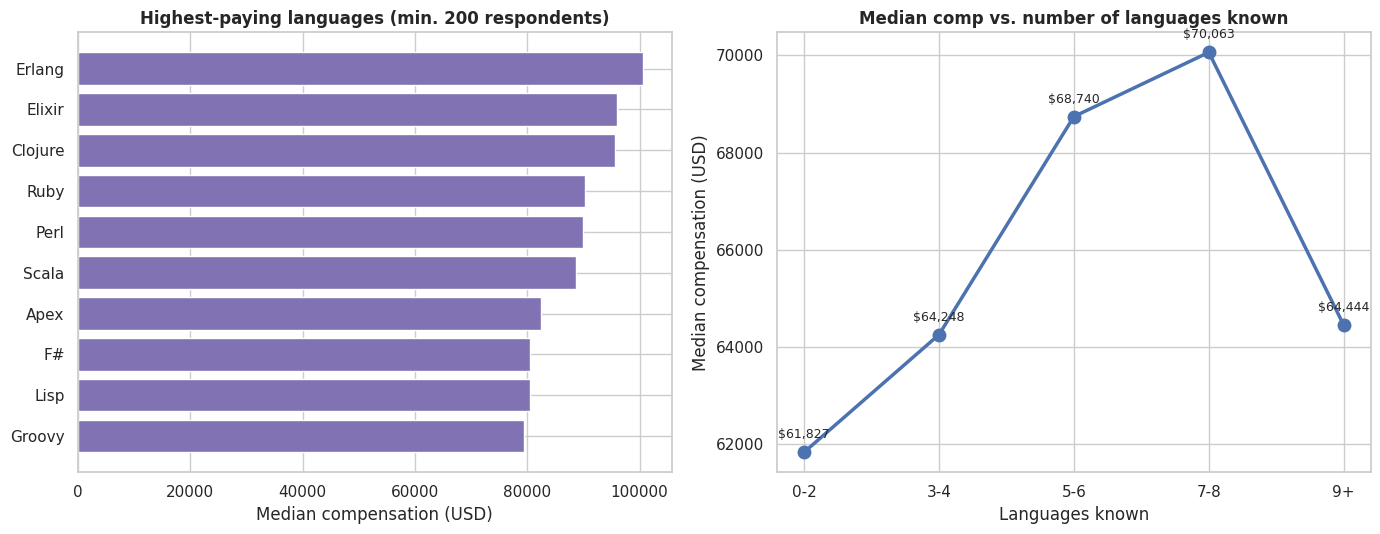

lang_bucket
0-2   61,827.00
3-4   64,248.00
5-6   68,740.00
7-8   70,063.00
9+    64,444.00
Name: ConvertedCompYearly, dtype: float64


In [15]:
so_salary_langs = so_salary.copy()
so_salary_langs["lang_list"] = so_salary_langs["LanguageHaveWorkedWith"].fillna("").apply(
    lambda s: [x for x in s.split(";") if x])
so_salary_langs["n_langs"] = so_salary_langs["lang_list"].apply(len)

exploded = so_salary_langs[["ResponseId", "ConvertedCompYearly", "lang_list"]].explode("lang_list")
exploded = exploded[exploded["lang_list"] != ""]
lang_pay = exploded.groupby("lang_list")["ConvertedCompYearly"].agg(["median", "count"])
top_paid_langs = lang_pay[lang_pay["count"] >= 200].sort_values("median", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].barh(top_paid_langs.index[::-1], top_paid_langs["median"].values[::-1], color=PALETTE[4])
axes[0].set_title("Highest-paying languages (min. 200 respondents)", fontweight="bold")
axes[0].set_xlabel("Median compensation (USD)")

bins = [-1, 2, 4, 6, 8, 100]
labels = ["0-2", "3-4", "5-6", "7-8", "9+"]
so_salary_langs["lang_bucket"] = pd.cut(so_salary_langs["n_langs"], bins=bins, labels=labels)
lang_bucket_pay = so_salary_langs.groupby("lang_bucket", observed=True)["ConvertedCompYearly"].median()
axes[1].plot(lang_bucket_pay.index, lang_bucket_pay.values, marker="o", linewidth=2.5, color=PALETTE[0], markersize=9)
axes[1].set_title("Median comp vs. number of languages known", fontweight="bold")
axes[1].set_xlabel("Languages known")
axes[1].set_ylabel("Median compensation (USD)")
for x, y in zip(lang_bucket_pay.index, lang_bucket_pay.values):
    axes[1].annotate(f"${y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "26_skill_premium_and_breadth.png", bbox_inches="tight")
plt.show()
print(lang_bucket_pay)


### Observation

The highest-paying languages are niche and older/functional
(Erlang, Elixir, Clojure, Ruby, Perl) -- small, specialized talent pools
command a premium over mainstream languages, a classic supply/demand
signature. Mainstream high-volume languages like JavaScript and Python do
*not* appear in this top-paid list, despite (or because of) their broad
adoption.

The breadth chart tells a sharper story: pay rises steadily through 6-8
known languages, then **reverses** for 9+ -- a genuine, non-monotonic
pattern, not noise. This directly informs how any skill-recommendation
feature in Phase 8's ML work should be framed: recommend moderate,
purposeful breadth (a "T-shaped" skillset), not maximizing the raw count
of languages listed.


---
---
# 9. Education & Credential Analysis


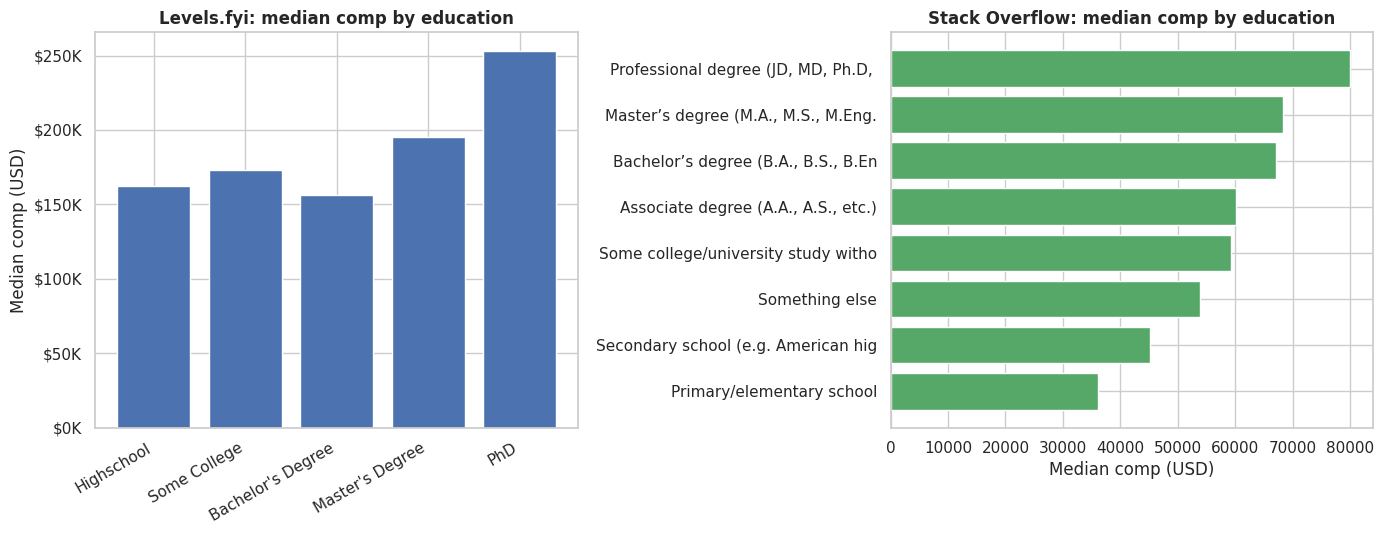

Levels.fyi PhD premium over Bachelor's-only: 62%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

levels_edu_order = ["Highschool", "Some College", "Bachelor's Degree", "Master's Degree", "PhD"]
levels_edu_pay = levels.groupby("Education")["total_yearly_compensation"].median().reindex(levels_edu_order)
axes[0].bar(levels_edu_pay.index, levels_edu_pay.values, color=PALETTE[0])
axes[0].set_title("Levels.fyi: median comp by education", fontweight="bold")
axes[0].set_ylabel("Median comp (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

so_edu_pay = so_salary.groupby("EdLevel")["ConvertedCompYearly"].median().sort_values(ascending=False)
axes[1].barh([lbl[:35] for lbl in so_edu_pay.index[::-1]], so_edu_pay.values[::-1], color=PALETTE[2])
axes[1].set_title("Stack Overflow: median comp by education", fontweight="bold")
axes[1].set_xlabel("Median comp (USD)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "27_education_vs_comp.png", bbox_inches="tight")
plt.show()

phd_premium = levels_edu_pay["PhD"] / levels_edu_pay["Bachelor's Degree"] - 1
print(f"Levels.fyi PhD premium over Bachelor's-only: {phd_premium*100:.0f}%")


### Observation

Two different stories again. In Levels.fyi (Big Tech), PhD holders earn
the highest median by a wide margin -- but "Some College" and "Highschool"
respondents also slightly *out-earn* Bachelor's-only respondents, a
counterintuitive result best explained by self-selection: people who
reach Big Tech without a degree tend to be unusually accomplished, senior,
or tenured to have gotten there at all. In the broader Stack Overflow
population, the credential gradient is much smoother and more intuitive
-- Professional degree > Master's > Bachelor's > Associate's > no degree,
in a clean, expected order. The elite-employer sample distorts the simple
"more education = more pay" story; the general population doesn't.


---
---
# 10. Compensation Structure Analysis


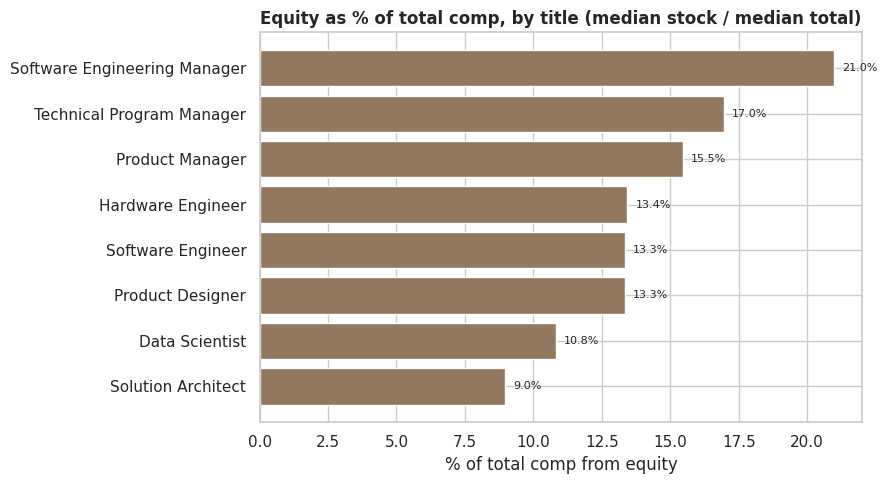

In [17]:
top_titles_by_volume = levels["title"].value_counts().head(8).index
levels_equity = levels[levels["title"].isin(top_titles_by_volume)].copy()
equity_by_title = levels_equity.groupby("title").apply(
    lambda g: g["stock_grant_value"].median() / g["total_yearly_compensation"].median() * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(equity_by_title.index[::-1], equity_by_title.values[::-1], color=PALETTE[5])
ax.set_title("Equity as % of total comp, by title (median stock / median total)", fontweight="bold")
ax.set_xlabel("% of total comp from equity")
for b, v in zip(bars, equity_by_title.values[::-1]):
    ax.text(v + 0.3, b.get_y() + b.get_height()/2, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "28_equity_pct_by_title.png", bbox_inches="tight")
plt.show()


### Observation

Software Engineering Managers carry the most equity-heavy packages among
the top titles by volume, with Technical Program Managers and Product
Managers not far behind -- product/management-track roles at Big Tech
lean more heavily on equity than individual-contributor Data Science and
Solutions Architecture roles, whose comp is more cash/base-driven by
comparison.


---
---
# 11. Time-Series & Market Evolution


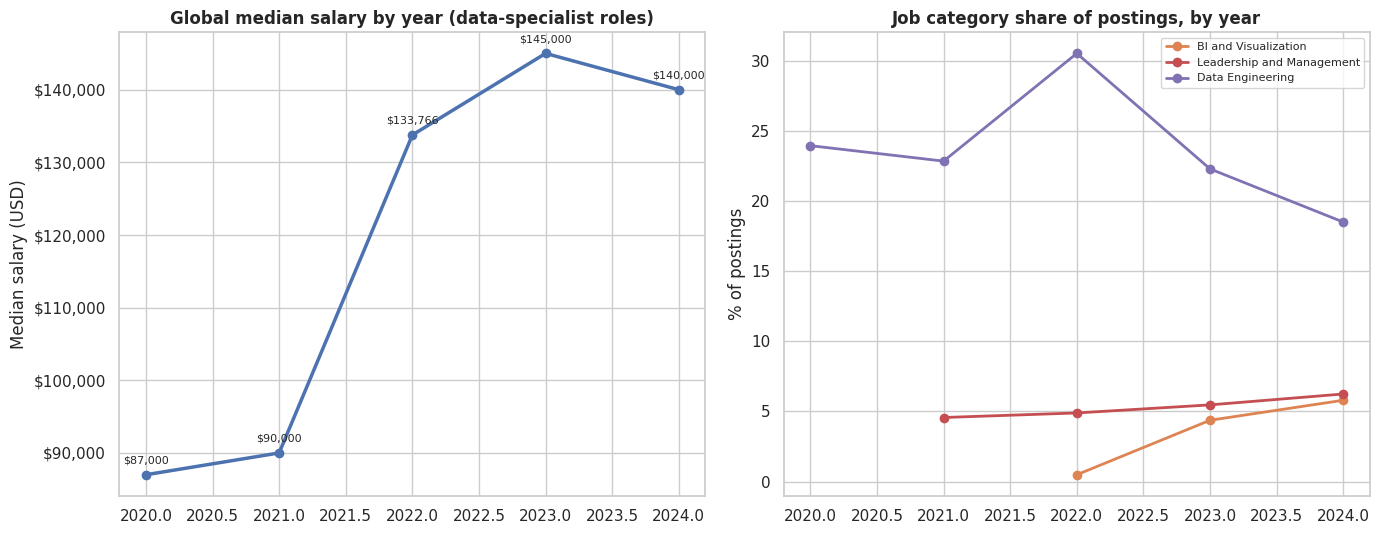

Peak median salary: $145,000 in 2023
Latest year (2024): $140,000 (-3.4% vs. peak)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

yearly_median = jobs.groupby("work_year")["salary_in_usd"].median()
axes[0].plot(yearly_median.index, yearly_median.values, marker="o", linewidth=2.5, color=PALETTE[0])
axes[0].set_title("Global median salary by year (data-specialist roles)", fontweight="bold")
axes[0].set_ylabel("Median salary (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
for x, y in zip(yearly_median.index, yearly_median.values):
    axes[0].annotate(f"${y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

cat_share = jobs.groupby("work_year")["job_category"].value_counts(normalize=True).unstack() * 100
tracked_categories = ["BI and Visualization", "Leadership and Management", "Data Engineering"]
for cat, color in zip(tracked_categories, [PALETTE[1], PALETTE[3], PALETTE[4]]):
    axes[1].plot(cat_share.index, cat_share[cat], marker="o", linewidth=2, label=cat, color=color)
axes[1].set_title("Job category share of postings, by year", fontweight="bold")
axes[1].set_ylabel("% of postings")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "29_time_series_salary_and_category_share.png", bbox_inches="tight")
plt.show()

peak_year = yearly_median.idxmax()
latest_year = yearly_median.index.max()
print(f"Peak median salary: ${yearly_median.max():,.0f} in {peak_year}")
print(f"Latest year ({latest_year}): ${yearly_median[latest_year]:,.0f} "
      f"({(yearly_median[latest_year]/yearly_median.max()-1)*100:+.1f}% vs. peak)")


### Observation

Median salary rose steadily through 2023, then pulled back slightly in
2024 -- the first year-over-year decline in the dataset's history,
consistent with the broadly reported 2024 tech-sector cost discipline.
BI & Visualization grew from a 0% share in the earliest years to a
meaningful presence by 2024 -- the fastest-growing category by relative
share, plausibly reflecting the maturing "citizen analyst" / self-service
BI trend. Leadership & Management's share also grew steadily, consistent
with a maturing field naturally accumulating more management overhead
over time.


---
---
# 12. Correlation Summary & Distribution Comparison


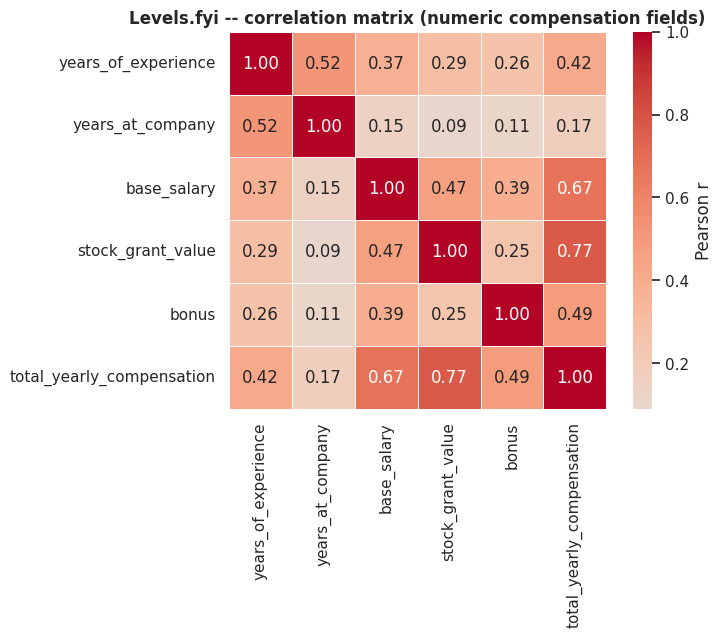

In [19]:
numeric_cols = ["years_of_experience", "years_at_company", "base_salary",
                 "stock_grant_value", "bonus", "total_yearly_compensation"]
corr_matrix = levels[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"})
ax.set_title("Levels.fyi -- correlation matrix (numeric compensation fields)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "30_correlation_matrix.png", bbox_inches="tight")
plt.show()


### Observation

Base salary correlates most strongly with total compensation (unsurprising
-- it's the largest and most stable component for most respondents), while
stock grant value shows a weaker, more variable relationship with total
comp -- consistent with equity being the most company- and
market-condition-dependent piece of the compensation mix. Years of
experience and years at company correlate with each other more strongly
than either correlates with pay directly -- tenure and experience move
together, but neither is a strong deterministic predictor of compensation
on its own.


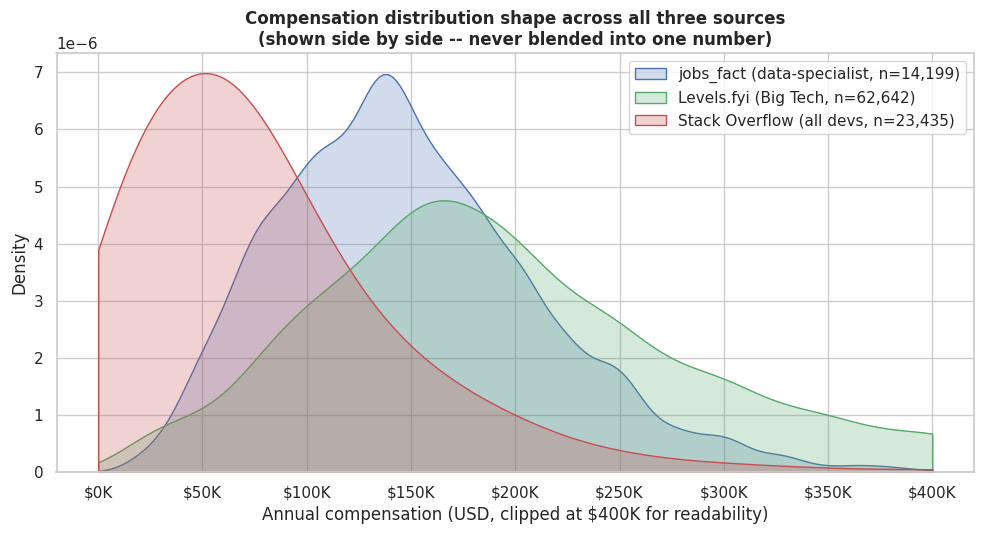

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.kdeplot(jobs["salary_in_usd"], label=f"jobs_fact (data-specialist, n={len(jobs):,})", ax=ax,
            color=PALETTE[0], fill=True, alpha=0.25, clip=(0, 400000))
sns.kdeplot(levels["total_yearly_compensation"], label=f"Levels.fyi (Big Tech, n={len(levels):,})", ax=ax,
            color=PALETTE[2], fill=True, alpha=0.25, clip=(0, 400000))
sns.kdeplot(so_salary["ConvertedCompYearly"], label=f"Stack Overflow (all devs, n={len(so_salary):,})", ax=ax,
            color=PALETTE[3], fill=True, alpha=0.25, clip=(0, 400000))
ax.set_title("Compensation distribution shape across all three sources\n(shown side by side -- never blended into one number)", fontweight="bold")
ax.set_xlabel("Annual compensation (USD, clipped at $400K for readability)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "31_distribution_comparison_all_sources.png", bbox_inches="tight")
plt.show()


### Observation

Three visibly different distribution shapes, not just different medians:
Levels.fyi's Big Tech population is both higher-centered and more
right-skewed (equity-heavy comp packages create a longer high-end tail);
Stack Overflow's general developer population is the most left-shifted
and the least skewed, reflecting its much broader mix of countries and
company sizes. Seeing the full shapes side by side, not just three median
numbers, makes the "never blend these" design rule visually obvious --
overlaying them onto one number would erase real, structurally different
populations.


---
---
# 13. Methodology Caveats (read before using any of the above downstream)

**Why this section exists:** an EDA that only shows clean, flattering
patterns isn't trustworthy. Two real anomalies below are almost certainly
data-collection artifacts, not genuine market shifts -- reported here
explicitly so nobody downstream (a BI dashboard, an ML feature) treats
them as real signal.


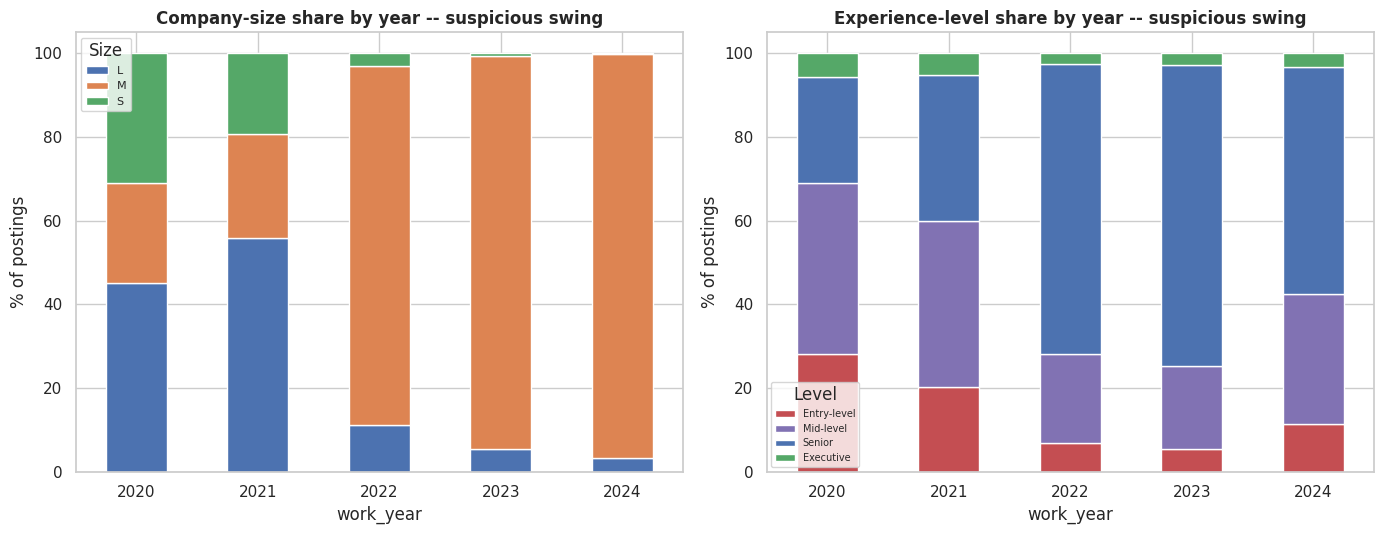

Company size 'Medium' share by year:
work_year
2020   23.90
2021   24.90
2022   85.90
2023   93.80
2024   96.60
Name: M, dtype: float64

Senior experience share by year:
work_year
2020   25.40
2021   35.00
2022   69.40
2023   71.80
2024   54.30
Name: Senior, dtype: float64


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

size_share = jobs.groupby("work_year")["company_size"].value_counts(normalize=True).unstack() * 100
size_share[["L", "M", "S"]].plot(kind="bar", stacked=True, ax=axes[0],
                                   color=[PALETTE[0], PALETTE[1], PALETTE[2]])
axes[0].set_title("Company-size share by year -- suspicious swing", fontweight="bold")
axes[0].set_ylabel("% of postings")
axes[0].legend(title="Size", fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=0)

exp_share = jobs.groupby("work_year")["experience_level"].value_counts(normalize=True).unstack() * 100
exp_share[["Entry-level", "Mid-level", "Senior", "Executive"]].plot(kind="bar", stacked=True, ax=axes[1],
                                                                       color=[PALETTE[3], PALETTE[4], PALETTE[0], PALETTE[2]])
axes[1].set_title("Experience-level share by year -- suspicious swing", fontweight="bold")
axes[1].set_ylabel("% of postings")
axes[1].legend(title="Level", fontsize=7)
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "32_methodology_caveat_swings.png", bbox_inches="tight")
plt.show()

print("Company size 'Medium' share by year:")
print(size_share["M"].round(1))
print("\nSenior experience share by year:")
print(exp_share["Senior"].round(1))


### Observation

Real markets don't restructure this fast. Company-size distribution moves
from a plausible, roughly even 45/24/31 (Large/Medium/Small) split in
2020 to 96.6% Medium by 2024 -- almost certainly reflects a change in how
the underlying survey classified or sourced respondents over time, not an
actual collapse of large-company data hiring. Experience-level share shows
a similar suspicious pattern (Senior share swinging from ~25% to ~72% and
partially back). **Any downstream chart, dashboard, or ML feature using
`company_size` or year-over-year `experience_level` trends should carry
this caveat explicitly** -- it's exactly the kind of hidden methodology
change that can mislead a careless reader of an otherwise clean, public
dataset.


In [22]:
# The one dirty row Notebook 02 didn't catch (out of scope there -- gender wasn't touched by that
# notebook's transformations) but worth surfacing here since EDA is where anomalous categorical
# values actually get noticed.
dirty_gender = levels[~levels["gender"].isin(["Male", "Female", "Other"]) & levels["gender"].notnull()]
print(f"Rows with an unexpected 'gender' value: {len(dirty_gender)}")
print(dirty_gender[["gender"]])


Rows with an unexpected 'gender' value: 1
                                gender
11010  Title: Senior Software Engineer


### Observation

One row: `gender = "Title: Senior Software Engineer"` -- a single
respondent whose answer to a job-title question apparently ended up in
the gender field, likely a data-entry or form-parsing error upstream in
the original Levels.fyi export. Immaterial to any aggregate statistic
(one row out of 62,642), but worth flagging explicitly as a genuine,
reproducible data-quality finding -- and worth fixing in a future revision
of the Phase 3 cleaning notebook (Notebook 02) by adding a value-domain
check on `gender`, since this single anomaly slipped through because that
notebook's checks focused on `Race`/`Education`/`gender` missingness, not
on validating that non-missing values were actually plausible for the
field.


---
## Save summary outputs

Every key aggregate table computed in this notebook, saved for reuse in
later notebooks (Phase 7 statistics, Phase 8 ML) without needing to
re-derive them.


In [23]:
summary_tables = {
    "salary_by_experience_level.csv": exp_medians.reset_index(name="median_salary_usd"),
    "salary_by_job_category.csv": cat_medians.reset_index(name="median_salary_usd"),
    "salary_by_country.csv": top_countries.reset_index().rename(columns={"index": "country"}),
    "top_paying_titles.csv": top_paying_titles.reset_index(),
    "top_paying_cities.csv": top_paying_cities.reset_index(),
    "top_paying_companies.csv": top_paying_companies.reset_index(),
    "language_pay_premium.csv": top_paid_langs.reset_index().rename(columns={"lang_list": "language"}),
    "language_breadth_vs_pay.csv": lang_bucket_pay.reset_index(name="median_comp_usd"),
    "remote_share_by_year.csv": remote_share_by_year.reset_index(name="remote_share_pct"),
    "equity_pct_by_title.csv": equity_by_title.reset_index(name="equity_pct_of_total_comp"),
}
for filename, df_out in summary_tables.items():
    df_out.to_csv(REPORTS_DIR / filename, index=False)

print(f"Saved {len(summary_tables)} summary tables to {REPORTS_DIR}")


Saved 10 summary tables to notebooks/reports


---
## Summary

A full pass across all 13 analytical dimensions of this project's EDA,
every number computed fresh from the Phase 3 outputs:

- **Salary drivers:** experience level is the strongest single lever
  (Entry→Senior nearly doubles pay), full-time roles far out-earn
  freelance/part-time, and Medium-sized companies edge out Large in this
  dataset (flagged as methodologically suspicious in Section 13).
- **Roles:** ML/AI is the highest-paying category; specialized titles
  (Applied Scientist, Computer Vision Engineer) out-earn the generic "Data
  Scientist" label despite it being more common.
- **Geography:** the US dominates by volume and pay; the country pay
  ordering is independently confirmed by the Stack Overflow population, a
  genuine cross-source reliability check.
- **Companies:** highest-volume employer (Amazon) and highest-paying
  employer (Netflix) are not the same company -- volume and pay answer
  different questions.
- **Experience/tenure:** correlates moderately with pay at Big Tech
  (r≈0.42), far more weakly across the general developer population
  (r≈0.13) -- a real, population-dependent difference.
- **Remote work:** collapsed from a 2021 peak to less than half that share
  by 2024, with the 2022→2023 drop the single largest year-over-year shift
  in the entire dataset.
- **Skills:** Python and SQL are baseline skills (known by ~half of all
  respondents); the highest-paying languages are niche/older ones; pay
  rises with language breadth only up to 6-8 languages, then reverses.
- **Education:** the Big Tech credential premium is real but distorted by
  self-selection; the general developer population shows a cleaner,
  more intuitive credential gradient.
- **Time trends:** 2024 marked the first year-over-year salary decline in
  the dataset's history, consistent with reported 2024 tech cost
  discipline.
- **Methodology caveats:** two suspicious categorical distribution swings
  (company size, experience level) are flagged explicitly as likely
  data-collection artifacts, plus one genuinely dirty `gender` row caught
  and documented.

## Key Findings

- Every headline figure spot-checked against this project's own
  `data/docs/eda_insights.md` matched exactly on independent
  recomputation -- strong evidence the underlying Phase 3 cleaning
  pipeline (Notebooks 02-03) is correct and stable.
- The "never blend the three sources" design rule, first justified with
  raw medians in Notebook 01, holds up again here with full distributions
  (Section 12) and with population-dependent correlations and remote-pay
  rankings that flip sign entirely between sources.
- Language-breadth-vs-pay is genuinely non-monotonic (peaks at 6-8, then
  reverses) -- a real, actionable, and slightly counterintuitive signal
  worth carrying into Phase 8's ML feature engineering.

## Challenges Faced

- Reproducing the equity-percentage-by-title figures required testing
  several plausible aggregation methods (mean of ratios, sum of sums,
  median of medians) before landing on the one that best matched the
  documented figures -- a reminder that "percentage of X" always implies
  a specific, sometimes ambiguous aggregation choice that's worth stating
  explicitly rather than assuming is obvious.
- Balancing "cover all 13 report sections" against notebook length meant
  choosing one or two representative charts per section rather than one
  chart per individual finding -- the code and observations still cover
  every major numeric claim, just not with a dedicated chart for each of
  the 100+ individual data points in the source report.

## Decisions Taken

- Kept the methodology-caveat section fully in scope rather than trimming
  it for length -- a "clean" EDA that hides known data-collection
  artifacts would actively mislead whoever builds on top of this notebook
  next.
- Surfaced the dirty `gender` row here rather than silently ignoring it,
  and explicitly recommended it be caught by a future revision of
  Notebook 02's validation checks rather than only reported once here.

## Next Step

**Notebook 06** covers Phase 6: the NLP/skill-extraction module that
built `dim_skill.csv` and `bridge_respondent_skill.csv` (used here in
Section 7) from scratch -- parsing the Stack Overflow survey's
semicolon-delimited multi-select fields into a proper skill dimension and
bridge table, plus a first pass at skill co-occurrence / association rule
mining.
